In [59]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [61]:
path = "../../data/processed/"
dfs = {}

# read all dataframes and keep them in dfs
for parquet in os.listdir(path):  # List all files in the directory
    if parquet.endswith(".parquet"):
        name = parquet.split(".parquet")[0]  # Get name without extension
        dfs[name] = pd.read_parquet(os.path.join(path, parquet))  # Use os.path.join for paths
        print(f"Loaded {name} with shape {dfs[name].shape}")

Loaded clean_df with shape (44205, 124)
Loaded taxones with shape (43783, 2319)
Loaded taxones_pressure with shape (43783, 2336)


In [62]:
df = dfs[list(dfs.keys())[1]]
df

SamplingOperations_code CodeSite_SamplingOperations  \
0          S02000008_20170703                   S02000008   
1          S02000008_20200708                   S02000008   
2          S02000010_20070906                   S02000010   
3          S02000010_20090721                   S02000010   
4          S02000010_20110723                   S02000010   
...                       ...                         ...   
43778      S06999141_20160928                   S06999141   
43779      S06999179_20230628                   S06999179   
43780      S06999180_20160928                   S06999180   
43781      S06999189_20160928                   S06999189   
43782      S06999189_20220920                   S06999189   

      Date_SamplingOperation  TotalAbundance_SamplingOperation  Achaa01  \
0                 2017-07-03                               405      0.0   
1                 2020-07-08                               400      0.0   
2                 2007-09-06                               400      0.0   
3                 2009-07-21                               400      0.0   
4                 2011-07-23                               398      0.0   
...                      ...                               ...      ...   
43778             2016-09-28                               403      0.0   
43779             2023-06-28                               409      0.0   
43780             2016-09-28                               404      0.0   
43781             2016-09-28                               403      0.0   
43782             2022-09-20                               406      0.0   

       Achac01  Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
0          0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
1          0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
2          0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
3          0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
4          0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
...        ...      ...      ...      ...      ...      ...      ...   
43778      0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
43779      0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
43780      0.0      0.0  0.00000      0.0      0.0      0.0      0.0   
43781      0.0      0.0  2.48139      0.0      0.0      0.0      0.0   
43782      0.0      0.0  0.00000      0.0      0.0      0.0      0.0   

        Achat02  Achat03  Achba01  Achbi01  Achbi02  Achbr01  Achca01  \
0      0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
1      0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
2      0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
3      0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
4      0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
...         ...      ...      ...      ...      ...      ...      ...   
43778  0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
43779  0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
43780  0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
43781  0.000000      0.0      0.0      0.0      0.0      0.0      0.0   
43782  4.926108      0.0      0.0      0.0      0.0      0.0      0.0   

       Achca02  Achca03  Achca04  Achch01  Achcl01  Achco01  Achco02  Achco03  \
0          0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
1          0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
2          0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
3          0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
4          0.0      0.0      0.0      0.0      0.0      0.0      0.0      0.0   
...        ...      ...      ...      ...      ...      ...      ...      ...   
43778      0.0      0.0      0.0      0.0      0.0      0.0    

In [64]:
# drop Longitude_Lambert93_x	Latitude_Lambert93_x	Watershed_x	CodeDepartement_x	HERlvl1Code_x	HERlvl1Name_x	HERlvl2Code_x	HERlvl2Name_x	Altitude_x	Streamsize_x
df = df.drop(columns=['Longitude_Lambert93_x','Latitude_Lambert93_x','CodeDepartement_x','HERlvl1Code_x','HERlvl1Name_x','HERlvl2Code_x','HERlvl2Name_x',])
df = df.set_index('SamplingOperations_code')
df

CodeSite_SamplingOperations Date_SamplingOperation  \
SamplingOperations_code                                                      
S02000008_20170703                        S02000008             2017-07-03   
S02000008_20200708                        S02000008             2020-07-08   
S02000010_20070906                        S02000010             2007-09-06   
S02000010_20090721                        S02000010             2009-07-21   
S02000010_20110723                        S02000010             2011-07-23   
...                                             ...                    ...   
S06999141_20160928                        S06999141             2016-09-28   
S06999179_20230628                        S06999179             2023-06-28   
S06999180_20160928                        S06999180             2016-09-28   
S06999189_20160928                        S06999189             2016-09-28   
S06999189_20220920                        S06999189             2022-09-20   

                         TotalAbundance_SamplingOperation  Achaa01  Achac01  \
SamplingOperations_code                                                       
S02000008_20170703                                    405      0.0      0.0   
S02000008_20200708                                    400      0.0      0.0   
S02000010_20070906                                    400      0.0      0.0   
S02000010_20090721                                    400      0.0      0.0   
S02000010_20110723                                    398      0.0      0.0   
...                                                   ...      ...      ...   
S06999141_20160928                                    403      0.0      0.0   
S06999179_20230628                                    409      0.0      0.0   
S06999180_20160928                                    404      0.0      0.0   
S06999189_20160928                                    403      0.0      0.0   
S06999189_20220920                                    406      0.0      0.0   

                         Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
SamplingOperations_code                                                         
S02000008_20170703           0.0  0.00000      0.0      0.0      0.0      0.0   
S02000008_20200708           0.0  0.00000      0.0      0.0      0.0      0.0   
S02000010_20070906           0.0  0.00000      0.0      0.0      0.0      0.0   
S02000010_20090721           0.0  0.00000      0.0      0.0      0.0      0.0   
S02000010_20110723           0.0  0.00000      0.0      0.0      0.0      0.0   
...                          ...      ...      ...      ...      ...      ...   
S06999141_20160928           0.0  0.00000      0.0      0.0      0.0      0.0   
S06999179_20230628           0.0  0.00000      0.0      0.0      0.0      0.0   
S06999180_20160928           0.0  0.00000      0.0      0.0      0.0      0.0   
S06999189_20160928           0.0  2.48139      0.0      0.0      0.0      0.0   
S06999189_20220920           0.0  0.00000      0.0      0.0      0.0      0.0   

                          Achat02  Achat03  Achba01  Achbi01  Achbi02  \
SamplingOperations_code                                                 
S02000008_20170703       0.000000      0.0      0.0      0.0      0.0   
S02000008_20200708       0.000000      0.0      0.0      0.0      0.0   
S02000010_20070906       0.000000      0.0      0.0      0.0      0.0   
S02000010_20090721       0.000000      0.0      0.0      0.0      0.0   
S02000010_20110723       0.000000      0.0      0.0      0.0      0.0   
...                           ...      ...      ...      ...      ...   
S06999141_20160928       0.000000      0.0      0.0      0.0      0.0   
S06999179_20230628       0.000000      0.0      0.0      0.0      0.0   
S06999180_20160928       0.000000      0.0      0.0      0.0      0.0   
S06999189_20160928       0.000000      0.0      0.0      0.0      0.0   
S06999189_20220920       4.926108      0.0      0.0

In [65]:
X = df.iloc[:,:-3]
y = df['IBD']

# Estaria muy interesante hacer uno con dates

In [66]:
X = X.drop(columns=['Date_SamplingOperation'])

# Cleaning the wide df

In [67]:
# Standard libraries
import os
from typing import List, Tuple

# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, mutual_info_regression, f_classif, f_regression
from sklearn.ensemble import RandomForestRegressor

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [68]:
def drop_exact_duplicates(X: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    """
    Drop exact duplicate columns from a DataFrame.

    This function identifies and removes columns in the DataFrame that are exact duplicates 
    of other columns. Duplicate columns are those that have identical values across all rows.

    Parameters:
    ----------
    X : pd.DataFrame
        The input DataFrame containing the features.

    Returns:
    -------
    Tuple[pd.DataFrame, List[str]]
        - A DataFrame with duplicate columns removed.
        - A list of the names of the dropped duplicate columns.

    Notes:
    -----
    - The function computes a hash signature for each column to efficiently identify duplicates.
    - If two columns have the same hash and their values are identical, one of them is dropped.

    Example Usage:
    --------------
    X, dropped_dup_cols = drop_exact_duplicates(X)
    print(f"Dropped exact duplicate columns: {dropped_dup_cols}")
    """
    sig = X.apply(lambda s: pd.util.hash_pandas_object(s, index=False).sum())
    seen = {}
    dup = []
    for c, h in sig.items():
        if h in seen and X[c].equals(X[seen[h]]):
            dup.append(c)
        else:
            seen[h] = c
    return X.drop(columns=dup), dup

# # Example usage:
# X, dropped_dup_cols = drop_exact_duplicates(X)
# print(f"Dropped exact duplicate columns: {dropped_dup_cols}")

In [69]:
def drop_high_missing(X: pd.DataFrame, thresh: float = 0.40) -> Tuple[pd.DataFrame, List[str]]:
    """
    Drop columns with a high proportion of missing values from a DataFrame.

    This function identifies columns in the DataFrame where the proportion of missing values 
    exceeds a specified threshold and removes them. Missing values are identified as NaN 
    or the string "Unassessed", which is replaced with NaN before processing.

    Parameters:
    ----------
    X : pd.DataFrame
        The input DataFrame containing the features.
    thresh : float, optional
        The proportion threshold above which a column is considered to have high missing values 
        and is dropped. Default is 0.40 (40%).

    Returns:
    -------
    Tuple[pd.DataFrame, List[str]]
        - A DataFrame with high-missing columns removed.
        - A list of the names of the dropped columns.

    Notes:
    -----
    - The function replaces the string "Unassessed" with NaN before calculating the proportion 
      of missing values.
    - Columns with a proportion of missing values greater than `thresh` are dropped.

    Example Usage:
    --------------
    X, dropped_cols = drop_high_missing(X, thresh=0.40)
    print(f"Dropped columns with >40% missing: {dropped_cols}")
    """
    # Replace "Unassessed" with NaN
    X = X.replace("Unassessed", np.nan)

    # Identify columns with a high proportion of missing values
    to_drop = X.columns[X.isna().mean() > thresh].tolist()

    # Drop the identified columns
    X2 = X.drop(columns=to_drop)

    return X2, to_drop


# # Example usage:
# X, dropped_cols = drop_high_missing(X, thresh=0.40)
# print(f"Dropped columns with >40% missing: {dropped_cols}")

In [70]:
def drop_quasi_constant_cat(
    X: pd.DataFrame, 
    cat_cols: List[str], 
    p: float = 0.99
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Drop quasi-constant categorical columns from a DataFrame.

    This function identifies categorical columns where the most frequent value 
    accounts for at least `p` proportion of the data and removes them from the DataFrame. 
    Quasi-constant columns are those that provide little variability and are unlikely 
    to be useful for modeling.

    Parameters:
    ----------
    X : pd.DataFrame
        The input DataFrame containing the features.
    cat_cols : List[str]
        A list of categorical column names to consider for quasi-constant checking.
    p : float, optional
        The proportion threshold above which a column is considered quasi-constant.
        Default is 0.99.

    Returns:
    -------
    Tuple[pd.DataFrame, List[str]]
        - A DataFrame with quasi-constant categorical columns removed.
        - A list of the names of the dropped quasi-constant categorical columns.

    Notes:
    -----
    - The function ensures that only columns present in the DataFrame are processed.
    - Missing values are included in the value counts when determining the most frequent value.

    Example Usage:
    --------------
    cat_cols = X.select_dtypes(exclude=['number']).columns
    X, dropped_cat_cols = drop_quasi_constant_cat(X, cat_cols.tolist(), p=0.99)
    print(f"Dropped quasi-constant categorical columns: {dropped_cat_cols}")
    """
    dropped = []
    for c in cat_cols:
        # Calculate the normalized value counts (including NaNs)
        vc = X[c].value_counts(normalize=True, dropna=False)
        
        # Check if the most frequent value exceeds the threshold
        if len(vc) and vc.iloc[0] >= p:
            dropped.append(c)
    
    # Drop the identified quasi-constant columns
    X2 = X.drop(columns=dropped)
    return X2, dropped


# # Example usage:
# cat_cols = X.select_dtypes(exclude=['number']).columns
# X, dropped_cat_cols = drop_quasi_constant_cat(X, cat_cols.tolist(), p=0.99)
# print(f"Dropped quasi-constant categorical columns: {dropped_cat_cols}")

In [71]:
def drop_high_cardinality_cat(
    X: pd.DataFrame, 
    cat_cols: List[str], 
    max_unique: int = 100, 
    ratio: float = 0.50
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Drop high-cardinality categorical columns from a DataFrame.

    This function identifies categorical columns with a high number of unique values 
    (cardinality) and removes them from the DataFrame. High-cardinality columns can 
    increase the complexity of the model and may not provide significant value.

    Parameters:
    ----------
    X : pd.DataFrame
        The input DataFrame containing the features.
    cat_cols : List[str]
        A list of categorical column names to consider for cardinality checking.
    max_unique : int, optional
        The maximum number of unique values allowed in a categorical column. 
        Default is 100.
    ratio : float, optional
        The maximum ratio of unique values to the total number of rows in the DataFrame.
        Default is 0.50.

    Returns:
    -------
    Tuple[pd.DataFrame, List[str]]
        - A DataFrame with high-cardinality categorical columns removed.
        - A list of the names of the dropped high-cardinality categorical columns.

    Notes:
    -----
    - A column is considered high-cardinality if the number of unique values exceeds 
      `max_unique` or if the ratio of unique values to the total number of rows exceeds `ratio`.
    - The function ensures that only columns present in the DataFrame are processed.

    Example Usage:
    --------------
    cat_cols = X.select_dtypes(exclude=['number']).columns
    X, dropped_high_card_cols = drop_high_cardinality_cat(X, cat_cols.tolist(), max_unique=100, ratio=0.50)
    print(f"Dropped high-cardinality categorical columns: {dropped_high_card_cols}")
    """
    n = len(X)
    lim = min(max_unique, int(ratio * n))
    dropped = [c for c in cat_cols if c in X.columns and X[c].nunique(dropna=False) > lim]
    X2 = X.drop(columns=dropped)
    return X2, dropped

# # Example usage:
# cat_cols = X.select_dtypes(exclude=['number']).columns
# X, dropped_high_card_cols = drop_high_cardinality_cat(X, cat_cols.tolist(), max_unique=100, ratio=0.50)
# print(f"Dropped high-cardinality categorical columns: {dropped_high_card_cols}")

In [72]:
def drop_quasi_constant_num(
    X: pd.DataFrame, num_cols: List[str], thresh: float = 1e-5
) -> Tuple[pd.DataFrame, List[str]]:
    """
    Drop quasi-constant numeric columns from a DataFrame.

    This function identifies numeric columns with very low variance (below a specified threshold)
    and removes them from the DataFrame. Quasi-constant columns are those that have almost the same
    value across all rows, which makes them uninformative for modeling.

    Parameters:
    ----------
    X : pd.DataFrame
        The input DataFrame containing the features.
    num_cols : List[str]
        A list of numeric column names to consider for variance checking.
    thresh : float, optional
        The variance threshold below which columns are considered quasi-constant.
        Default is 1e-5.

    Returns:
    -------
    Tuple[pd.DataFrame, List[str]]
        - A DataFrame with quasi-constant numeric columns removed.
        - A list of the names of the dropped quasi-constant numeric columns.

    Notes:
    -----
    - Missing values in the numeric columns are imputed using the median before calculating variance.
    - The VarianceThreshold from sklearn is used to identify quasi-constant columns.
    """
    if not num_cols:
        return X, []

    # Impute missing values with the median
    imp = SimpleImputer(strategy="median")
    Xn = pd.DataFrame(imp.fit_transform(X[num_cols]), columns=num_cols, index=X.index)

    # Apply VarianceThreshold to identify columns with low variance
    vt = VarianceThreshold(threshold=thresh)
    vt.fit(Xn)

    # Identify kept and dropped columns
    kept = [c for c, k in zip(num_cols, vt.get_support()) if k]
    dropped = [c for c in num_cols if c not in kept]

    # Drop the quasi-constant columns from the original DataFrame
    X2 = X.drop(columns=dropped)
    return X2, dropped


# # Example usage:
# num_cols = X.select_dtypes(include=['number']).columns  # Select numeric columns
# X, dropped_num_cols = drop_quasi_constant_num(X, num_cols.tolist(), thresh=1e-5)
# print(f"Dropped quasi-constant numeric columns: {dropped_num_cols}")

In [73]:
def prefilter_num_univariate(
    X: pd.DataFrame, y: pd.Series, num_cols: List[str], k: int = 300
) -> Tuple[pd.DataFrame, List[str], pd.Series]:
    """
    Perform a univariate feature selection for numeric columns based on their relationship with the target variable.

    This function selects the top `k` numeric features that have the highest scores in a univariate statistical test 
    (ANOVA F-value for classification or F-statistic for regression) with respect to the target variable `y`.

    Parameters:
    ----------
    X : pd.DataFrame
        The input dataframe containing features.
    y : pd.Series
        The target variable.
    num_cols : List[str]
        A list of numeric column names to consider for feature selection.
    k : int, optional
        The number of top features to keep, by default 300.

    Returns:
    -------
    Tuple[pd.DataFrame, List[str], pd.Series]
        - A dataframe containing the top `k` numeric features.
        - A list of the names of the selected top `k` numeric features.
        - A pandas Series containing the scores of all numeric features, sorted in descending order.

    Notes:
    -----
    - If the target variable `y` is numeric and has more than 20 unique values, the function uses `f_regression`.
      Otherwise, it uses `f_classif`.
    - Missing values in the numeric columns are imputed using the median before calculating the scores.
    """
    # Filter numeric columns that exist in the dataframe
    keep = [c for c in num_cols if c in X.columns]
    if not keep:
        return X, [], pd.Series(dtype=float)

    # Impute missing values with the median
    Xi = pd.DataFrame(
        SimpleImputer(strategy="median").fit_transform(X[keep]),
        columns=keep, index=X.index
    )

    # Select the appropriate statistical test based on the target variable type
    if np.issubdtype(y.dtype, np.number) and y.nunique() > 20:
        scores, _ = f_regression(Xi, y.to_numpy())
    else:
        scores, _ = f_classif(Xi, y.to_numpy())

    # Create a pandas Series of scores, sort them in descending order
    s = pd.Series(scores, index=keep).fillna(0.0).sort_values(ascending=False)

    # Select the top `k` features
    top = s.index[: min(k, len(s))].tolist()

    # Return the top features, their names, and the scores
    return pd.concat([Xi[top]], axis=1), top, s

# # Example usage:
# Xnum, top_num_cols, f_scores = prefilter_num_univariate(X, y, num_cols.tolist(), k=300)

In [ ]:
Xnum

,Achmi02,Achpy01,Altitude_x,Navsa03,Selni01,Navpe05,Navsu09,Nitpa01,Achla02,Navgr01,Gompa06,Nitam01,Crasu01,Achli03,Achri01,Nitin02,Navve03,Selsa02,Achsu01,Gomel01,Navmo05,Fragr01,Cymsi01,Navge02,Nitpa02,Cocli01,Nitso04,Navan05,Cymve01,Navla04,Encmi04,Cymmi01,Coceu01,Cycps01,Nitsu09,Gomrh01,Synde01,Navcr04,Hipca02,Amppe02,Gomex01,Nitsu01,Rhoab01,Selpu01,Gomte02,Achob01,Gomol04,Dente01,Nitca03,Cymex01,Melva01,Navtr05,Achat02,Navsu03,Achho03,Navan02,Gomin06,Navcr05,Achaf02,Encsu03,Lutgo01,Psahe01,Navsi04,Selat01,Stein01,Cycdu01,Steha01,Navca08,Achge01,Nitfr02,Diame01,Eunte01,Cycme02,Gomla05,Achmi03,Cycat01,Nitgr02,Surla01,Goman05,Gombo02,Suran01,Naver01,Eunin01,Nitpu04,Surbr01,Navno02,Cymaf02,Himmi01,Ampve01,Gomli05,Diaeh01,Encne01,Karcl01,Micpo01,Plala02,Diaco01,Tabfl01,Nitac04,Diamo01,Navvi01,Navac02,Navca07,Nitfi02,Cymex02,Encmi03,Navst05,Fravi02,Achde02,Cycme01,Bacpa01,Stete01,Navar02,Tryap01,Nitso01,Achsu03,Eunim01,Nitmi01,Frape01,Ampat01,Halmo01,Nitfr01,Navat02,Gomca02,Navca11,Navte01,Psabi01,Nitli03,Cocpa01,Nupla01,Fraru01,Nitau01,Himex01,Eolco01,Cymaf01,Navam05,Navex02,Nitin04,Parpr01,Sursu02,Plaob01,Nitde03,Plesc01,Gommi02,Eunsu02,Frapa01,Gyrac01,Frane04,Nitlo01,Plami02,Nitre01,Neial01,Gomva02,Acheu01,Eucla01,Falpy01,Nithu01,Fraau01,Fruco01,Mayin01,Psave01,Psaob01,Tryle01,Didge01,Tabfa01,Achda01,Tryde01,Nitso02,Achla04,Achco02,Navpr03,Nitdi03,Aulgr01,Achex01,Brane01,Tryca01,Homco01,Delde02,Eunbo03,Ampov01,Pratr01,Nitli01,Brane02,Navva03,Navmu06,Tryco02,Gomca01,Ampmo01,Nitde06,Navbu01,Eunbi05,Plasa01,Nitad01,Navsy01,Micgr01,Navsc04,Amppe01,Navcr01,Gommi01,Gomme01,Fruer01,Dipse01,Tryku01,Cocpe01,Plaro03,Rosan01,Nitag01,Navob06,Stetr01,Pinpe03,Merci01,Navve06,Nitla03,Hanar01,Achre01,Cycdi01,Gomte01,Navum01,Nitdi04,Achco04,Frusa01,Navmi07,Nittr02,Plaro04,Eunpa02,Nitso03,Gomcy01,Achzh01,Nitpu01,Steve01,Prepr02,Fraca04,Achro04,Frucu01,Cymtr01,Navcr09,Cymso01,Cocpl01,Navme03,Merco01,Hombu01,Surro01,Nitco07,Conwe01,Plela01,Melte01,Achkr02,Achca02,Achsu06,Achsa01,Achhu01,Gomol03,Gommi05,Gomau01,Nitte02,Plaap01,Pleku01,Nittu01,Navvi02,Navci01,Nitfo01,Aulam01,Eunrh01,Navar04,Gomit01,Pse(a01,Cymbe01,Nitcl01,Thaps01,Achst03,Navra01,Perfi01,Melpu01,Encvu01,Navha02,Nitsi01,Eunar03,Fraex01,Eunsi01,Encce01,Navmo08,Prepr01,Gomho02,Navmi02,Adlbr02,Navam02,Gomco05,Nitdu01,Frapa02,Reiun01,Lutve01,Pleob01,Delal01,Nitag02,Surde01,Gomoc01,Goman04,Plesa01,Psaco01,Navme04,Gomac02
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S02000008_20170703,88.888889,0.000000,0.0,283.950617,14.814815,261.728395,19.753086,0.000000,7.407407,0.00000,4.938272,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,2.469136,0.00000,0.0,0.000000,0.000000,44.444444,0.0,0.0,0.0,0.0,0.0,0.0,187.654321,0.0,0.0,7.407407,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.407407,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,2.469136,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.469136,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32.098765,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.

In [74]:
def drop_zeros(X: pd.DataFrame, thresh: float = 0.95) -> Tuple[pd.DataFrame, List[str]]:
    """
    Drop columns with a high proportion of zero values from a DataFrame.

    This function identifies columns in the DataFrame where the proportion of zero values 
    exceeds a specified threshold and removes them. Columns with a high proportion of zeros 
    are often uninformative and can be excluded from further analysis.

    Parameters:
    ----------
    X : pd.DataFrame
        The input DataFrame containing the features.
    thresh : float, optional
        The proportion threshold above which a column is considered to have high zero values 
        and is dropped. Default is 0.95 (95%).

    Returns:
    -------
    Tuple[pd.DataFrame, List[str]]
        - A DataFrame with high-zero columns removed.
        - A list of the names of the dropped columns.

    Notes:
    -----
    - The function calculates the proportion of zero values in each column.
    - Columns with a proportion of zero values greater than `thresh` are dropped.

    Example Usage:
    --------------
    Xnum, dropped_cols = drop_zeros(Xnum, thresh=0.95)
    print(f"Dropped columns with >95% zeros: {dropped_cols}")
    """
    # Identify columns with a high proportion of zero values
    to_drop = X.columns[(X == 0).mean() > thresh].tolist()

    # Drop the identified columns
    X = X.drop(columns=to_drop)

    return X, to_drop


# # Example usage:
# Xnum, dropped_cols = drop_zeros(Xnum, thresh=0.95)
# print(f"Dropped columns with >95% zeros: {dropped_cols}")

In [75]:
# Example usage:
X, dropped_dup_cols = drop_exact_duplicates(X)
print(f"Dropped exact duplicate columns: {dropped_dup_cols}")

# Example usage:
X, dropped_cols = drop_high_missing(X, thresh=0.40)
print(f"Dropped columns with >40% missing: {dropped_cols}")

# Example usage:
cat_cols = X.select_dtypes(exclude=['number']).columns
X, dropped_cat_cols = drop_quasi_constant_cat(X, cat_cols.tolist(), p=0.99)
print(f"Dropped quasi-constant categorical columns: {dropped_cat_cols}")


# Example usage:
cat_cols = X.select_dtypes(exclude=['number']).columns
X, dropped_high_card_cols = drop_high_cardinality_cat(X, cat_cols.tolist(), max_unique=100, ratio=0.50)
print(f"Dropped high-cardinality categorical columns: {dropped_high_card_cols}")

# Example usage:
num_cols = X.select_dtypes(include=['number']).columns  # Select numeric columns
X, dropped_num_cols = drop_quasi_constant_num(X, num_cols.tolist(), thresh=1e-5)
print(f"Dropped quasi-constant numeric columns: {dropped_num_cols}")

# Example usage:
Xnum, top_num_cols, f_scores = prefilter_num_univariate(X, y, num_cols.tolist(), k=300)

# Example usage:
Xnum, dropped_cols = drop_zeros(Xnum, thresh=0.95)
print(f"Dropped columns with >95% zeros: {dropped_cols}")

Dropped exact duplicate columns: ['Actde01', 'Adlaq01', 'Birbi01', 'Calla01', 'Cenre01', 'Cochu02', 'Cocps01', 'Cycex01', 'Cyman04', 'Cymel02', 'Cympr01', 'Diavi01', 'Dipbo02', 'Dipde01', 'Dippa01', 'Enchu01', 'Encla01', 'Encsu01', 'Encsu02', 'Ethpu01', 'Eucau01', 'Eungi01', 'Frape02', 'Gomca03', 'Grama01', 'Hipps01', 'Meldi02', 'Melly01', 'Melny01', 'Mesme01', 'Navel01', 'Navge03', 'Navgr02', 'Navha08', 'Navin02', 'Navme02', 'Navmo10', 'Navpa03', 'Navpa06', 'Navpe02', 'Navra03', 'Navre01', 'Navre06', 'Navsc05', 'Navsu17', 'Navsy02', 'Navth01', 'Navto01', 'Navtr01', 'Navum02', 'Nitla04', 'Nitmi04', 'Nitpl01', 'Nitta01', 'Nitth01', 'Nitzu01', 'Nuppa01', 'Opemi01', 'Parhe01', 'Pinin03', 'Pinsu08', 'Plala01', 'Plame01', 'Plami01', 'Plata01', 'Psebo01', 'Semro01', 'Stapo01', 'Stapu01', 'Surol01', 'Synaf01', 'Thani01', 'Watershed_y']
Dropped columns with >40% missing: []
Dropped quasi-constant categorical columns: []
Dropped high-cardinality categorical columns: ['CodeSite_SamplingOperation

In [76]:
num_cols = X.select_dtypes(include=['number']).columns
cat_cols = X.columns.difference(num_cols)

In [77]:
# merge both that have the same index
Xclean = pd.concat([Xnum, X[cat_cols]], axis=1)
Xclean

,IBD_EQR,Achmi02,Achpy01,Altitude_x,Navsa03,Selni01,Navpe05,Navsu09,Nitpa01,Achla02,Latitude_Lambert93_y,Navgr01,HERlvl1Code_y,Gompa06,Nitam01,Crasu01,Achli03,Achri01,Nitin02,Navve03,Selsa02,Achsu01,Gomel01,Navmo05,Fragr01,Cymsi01,Navge02,Nitpa02,Cocli01,Nitso04,Navan05,Cymve01,Navla04,Cymmi01,Coceu01,Cycps01,Nitsu09,Longitude_Lambert93_y,Synde01,Navcr04,Hipca02,Amppe02,Gomex01,Nitsu01,Rhoab01,Selpu01,Gomte02,Achob01,Gomol04,Dente01,Nitca03,Cymex01,Melva01,Navtr05,Achat02,Navsu03,Gomin06,Navcr05,Lutgo01,Navsi04,Selat01,Stein01,Cycdu01,Steha01,Navca08,Achge01,Cycme02,Cycat01,Surla01,Gombo02,Suran01,Nitpu04,Surbr01,Karcl01,Plala02,Nitac04,Navvi01,Navca07,Nitso01,Achsu03,Frape01,Ampat01,Navat02,Navca11,Nitli03,Nitde03,Plesc01,Nitre01,Acheu01,Fruco01,Achla04,Achco02,Ampov01,Dipse01,Cocpe01,Merci01,Nitdi04,Plaro04,Navcr09,Cocpl01,Nitco07,Achca02,Gommi05,Nitfo01,Aulam01,HERlvl2Code_y,Achst03,Melpu01,Reiun01,CodeDepartement_y,HERlvl1Name_y,IBD_EQR_Status,Streamsize_x,Watershed_x
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S02000008_20170703,0.502924,88.888889,0.000000,0.0,283.950617,14.814815,261.728395,19.753086,0.000000,7.407407,6721258.0,0.00000,18.0,4.938272,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,2.469136,0.00000,0.0,0.000000,44.444444,0.0,0.0,1039055.0,0.0,0.0,0.0,187.654321,0.0,0.0,7.407407,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,7.407407,0.0,0.0,0.00000,2.469136,0.0,0.0,0.0,2.469136,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.00000,0.0,0.000000,0.0,32.098765,0.000000,0.000000,0.0,0.000000,0.000000,0.0,73.0,2.469136,0.0,0.000000,68,ALSACE,Poor,TP,Rhin-Meuse
S02000008_20200708,0.409357,12.500000,0.000000,0.0,432.500000,15.000000,195.000000,0.000000,5.000000,7.500000,6721258.0,0.00000,18.0,0.000000,0.0,25.0,0.000000,0.0,0.000000,12.500000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.00000,10.0,0.000000,10.000000,0.0,0.0,1039055.0,0.0,0.0,0.0,2.500000,0.0,0.0,25.000000,12.5,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,5.0,0.000000,0.0,0.000000,7.5,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,2.5,0.0,0.000000,0.0,0.000000,0.0,2.500000,0.0,0.0,5.00000,0.000000,0.0,0.0,5.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,5.00000,0.0,7.500000,0.0,137.500000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,73.0,0.000000,0.0,0.000000,68,ALSACE,Poor,TP,Rhin-Meuse
S02000010_20070906,0.777778,0.000000,0.000000,246.0,17.500000,0.000000,2.500000,0.000000,75.000000,0.000000,6737723.0,52.50000,18.0,5.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,5.0,2.500000,0.0,0.0,2.5,0.000000,10.000000,0.00000,5.0,0.000000,12.500000,0.0,5.0,1039381.0,0.0,0.0,0.0,25.000000,0.0,0.0,10.000000,0.0,0.0,0.0,7.500000,0.0,0.0,5.000000,27.500000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67.500000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,15.000000,0.0,0.000000,0.0,0.0,35.00000,25.000000,0.0,0.0,0.0,10.000000,0.0,0.000000,0.000000,0.000000,0.000000,2.5,0.000000,0.0,0.0,0.000000,0.000000,2.50000,0.0,147.500000,0.0,117.500000,0.000000,0.000000,0.0,5.000000,5.000000,0.0,62.0,0.000000,0.0,0.000000,68,ALSACE,Moderate,None,Rhin-Meuse
S02000010_20090721,0.818713,135.000000,7.500000,246.0,7.500000,22.500000,12.500000,5.000000,0.000000,15.000000,6737723.0,22.50000,18.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,2.500000,0.0,2.5,0.0,0.0,0.0,0.000000,0.0,32.5,0.0,0.000000,5.000000,15.00000,2.5,0.000000,72.500000,27.5,0.0,1039381.0,0.0,0.0,0.0,47.500000,0.0,0.0,32.500000,0.0,7.5,0.0,0.000000,0.0,0.0,0.000000,2.500000,0.0,0.000000,2.5,0.000000,0.0,0.0,0.0,0.0,0.0,2.5,0.0,0.000000,2.5,10.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,7.500000,0.0,0.0,0.00000,0.000000,0.0,0.0,5.0,0.000000,0.0,0.000000,0.000000,0.000

In [40]:
cleandf = pd.merge(Xclean, y, left_index=True, right_index=True)
cleandf.to_parquet("../../data/processed/clean_df.parquet")

# Random Forest Classifier for IBD

In [ ]:
# 2) Identify column types
num_cols = Xclean.select_dtypes(include=['number']).columns
cat_cols = Xclean.columns.difference(num_cols)

# 3) Preprocess
# this preprocessor can handle missing values   
pre = ColumnTransformer([
    ('num', Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler(with_mean=False))  # stays sparse with OHE
    ]), num_cols),
    ('cat', Pipeline([
        ('imp', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore'))
    ]), cat_cols)

])

# 4) Model
clf = Pipeline([
    ('pre', pre),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))  # for regression
])  

In [31]:
# 5) Train/test
X_tr, X_te, y_tr, y_te = train_test_split(
    Xclean, y, test_size=0.2,
    stratify=y if y.nunique()<=20 else None,
    random_state=42
)

In [32]:
clf.fit(X_tr, y_tr)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

yhat = clf.predict(X_te)

# Calculate regression metrics
mse = mean_squared_error(y_te, yhat)
mae = mean_absolute_error(y_te, yhat)
r2 = r2_score(y_te, yhat)

print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")
print(f"R2 Score: {r2}")

Mean Squared Error: 0.7238849809788043
Mean Absolute Error: 0.5332663107609152
R2 Score: 0.9097291236593544


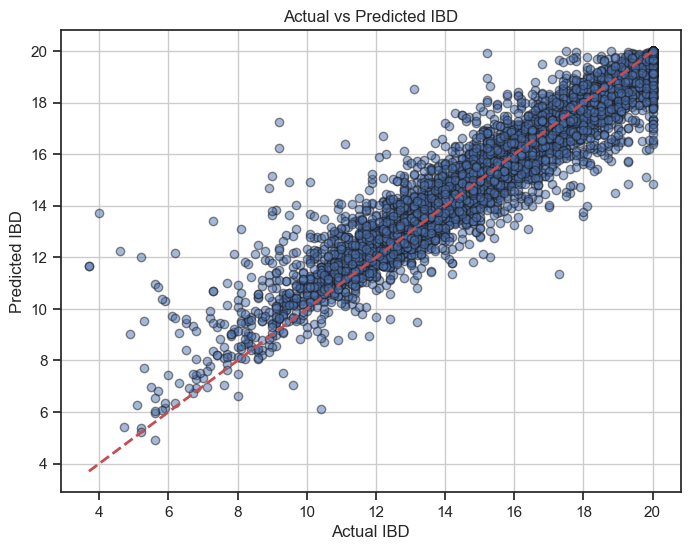

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_te, yhat, alpha=0.5, edgecolor='k')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
plt.xlabel('Actual IBD')
plt.ylabel('Predicted IBD')
plt.title('Actual vs Predicted IBD')
plt.grid(True)
plt.show()

In [38]:
# save the model
import joblib
joblib.dump(clf, 'first_random_forest.joblib')

['first_random_forest.joblib']

In [37]:
# can i know if S04207000_20130812 is in the training set?
code = "S04207000_20130812"
code in Xclean.index

False

In [ ]:
# ---------- Step 4: drop highly correlated numeric ----------
def drop_high_corr_num(X: pd.DataFrame, num_cols: List[str], corr_thresh: float = 0.95) -> Tuple[pd.DataFrame, List[str]]:
    keep = [c for c in num_cols if c in X.columns]
    if not keep:
        return X, []
    imp = SimpleImputer(strategy="median")
    Xn = pd.DataFrame(imp.fit_transform(X[keep]), columns=keep, index=X.index)
    corr = Xn.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    dropped = [c for c in upper.columns if any(upper[c] > corr_thresh)]
    X2 = X.drop(columns=dropped)
    return X2, dropped

In [ ]:
# ---------- Step 5: mutual information selector ----------
def mi_select(
    X: pd.DataFrame, y: pd.Series, num_cols: List[str], cat_cols: List[str],
    k: int = 50, random_state: int = 0
) -> Tuple[List[str], pd.Series]:
    # imputations
    num_cols = [c for c in num_cols if c in X.columns]
    cat_cols = [c for c in cat_cols if c in X.columns]
    if num_cols:
        Xn = SimpleImputer(strategy="median").fit_transform(X[num_cols])
    else:
        Xn = np.empty((len(X), 0))
    if cat_cols:
        Xc_imp = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])
        enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        Xc = enc.fit_transform(Xc_imp)
    else:
        Xc = np.empty((len(X), 0))
    Xenc = np.hstack([Xn, Xc])
    discrete_mask = np.r_[np.zeros(Xn.shape[1], dtype=bool), np.ones(Xc.shape[1], dtype=bool)]
    # choose MI function
    if np.issubdtype(y.dtype, np.number) and y.nunique() > 20:
        mi = mutual_info_regression(Xenc, y.to_numpy(), discrete_features=discrete_mask, random_state=random_state)
    else:
        mi = mutual_info_classif(Xenc, y.to_numpy(), discrete_features=discrete_mask, random_state=random_state)
    cols = num_cols + cat_cols
    mi_s = pd.Series(mi, index=cols).sort_values(ascending=False)
    keep = mi_s.index[: min(k, len(cols))].tolist()
    return keep, mi_s

# XGboost Regressor for IBD

In [ ]:
# # pip install xgboost
# from xgboost import XGBRegressor

# gpu_xgb = Pipeline([
#     ('pre', pre),  # your ColumnTransformer with OHE/scale
#     ('model', XGBRegressor(
#         tree_method='gpu_hist', predictor='gpu_predictor',
#         n_estimators=2000, max_depth=8, learning_rate=0.05,
#         subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
#         random_state=42
#     ))
# ])
# gpu_xgb.fit(Xtr, ytr, eval_set=[(Xte, yte)], eval_metric='auc', verbose=200, early_stopping_rounds=200)


# Catboost Regressor for IBD

In [ ]:
# # pip install catboost
# from catboost import CatBoostRegressor, Pool
# from sklearn.model_selection import train_test_split

# X = df.drop(columns=['IBD'])
# y = df['IBD']

# num_cols = X.select_dtypes(include='number').columns
# cat_cols = [c for c in X.columns if c not in num_cols]   # keep as object/string or int codes

# Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# train_pool = Pool(Xtr, ytr, cat_features=cat_cols)
# valid_pool = Pool(Xte, yte, cat_features=cat_cols)

# model = CatBoostRegressor(
#     task_type="GPU", devices="0",
#     iterations=5000, learning_rate=0.05, depth=8,
#     loss_function="RMSE", eval_metric="RMSE",
#     verbose=200
# )
# model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=200)
